In [251]:
import torch
import pandas as pd
import numpy as np
import random
import torch.optim as optim

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sn
from torch.utils.data import DataLoader, TensorDataset

In [252]:
from kan import KAN

In [253]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [254]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [255]:
FILE_PATH = r".\diabetes.csv"
df = pd.read_csv(FILE_PATH, header=0)

df = df.rename(columns={"Outcome": "Diagnosis"})

df.describe()
df = pd.read_csv(FILE_PATH, header=0)

df = df.rename(columns={"Outcome": "Diagnosis"})

df.describe()
columns_to_fix_med = ['Glucose', 'BloodPressure']
columns_to_fix_mea = ['BMI','SkinThickness','Insulin']

for col in columns_to_fix_mea:
    zero_count = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    
    mean_value = df[col].mean()
    df[col] = df[col].replace(np.nan, mean_value)
    
for col in columns_to_fix_med:
    zero_count = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    
    median_value = df[col].median()
    df[col] = df[col].replace(np.nan, median_value)

In [256]:
X = df.drop(columns=["Diagnosis"]).values
y = df["Diagnosis"].values
y = y.reshape(-1, 1) 

scaler= StandardScaler()
X = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

scaler= StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1) 

X_test_org = torch.tensor(X_test, dtype=torch.float32)
y_test_org = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_val, dtype=torch.float32)
y_test_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)


In [257]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [258]:
input_size = X.shape[1]

In [259]:
#TODO
train_loader = DataLoader(train_dataset,
                          batch_size=64,
                          shuffle=False)

test_loader = DataLoader(test_dataset,
                         batch_size=64,
                         shuffle=False )



In [260]:
import torch.nn as nn
class MLP(nn.Module):
    def __init__(self, input_size, dropout_p=0.5):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size,32), 
            nn.BatchNorm1d(32),
            nn.ReLU(), 
            nn.Dropout(dropout_p),                
            
            nn.Linear(32, 64), 
            nn.BatchNorm1d(64),
            nn.ReLU(),      
            
            nn.Linear(64, 16), 
            nn.BatchNorm1d(16),
            nn.ReLU(),      
            nn.Dropout(dropout_p * 0.6),   

            nn.Linear(16, 1),          
            # nn.Sigmoid()               
        )
    def forward(self, x):
        return self.model(x)

In [261]:
#TODO
input_size = X.shape[1]
model = MLP(input_size,dropout_p=0.4).to(device)
criterion = nn.BCEWithLogitsLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
NUM_EPOCHS = 50

In [262]:
metrics_df = pd.DataFrame(columns=["Epoch", 
                                   "Train_Loss", "Train_Accuracy", 
                                    "Val_Loss", 
                                   "Val_Accuracy"])


In [263]:
train_accuracy_list= []
test_accuracy_list= []

#TODO
for epoch in range(NUM_EPOCHS):
    model.train()
    total=0
    corrects= 0
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs= inputs.to(device)
        labels= labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() 
        total += labels.size(0)
        outputs=torch.sigmoid(outputs)
        predicted = (outputs > 0.5).float()
        corrects += (predicted == labels).sum().item()

    train_accuracy= corrects / total
    train_loss = running_loss / len(train_loader)
    train_accuracy_list.append(train_accuracy)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {train_loss:.4f}, Acurracy= {train_accuracy:.4f}")

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs= inputs.to(device)
            labels= labels.to(device)
            loss = criterion(model(inputs), labels)
            val_loss = loss.item()
            
            outputs = model(inputs)
            outputs=torch.sigmoid(outputs)
            predicted = (outputs > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
            outputs = model(X_test_org.to(device))
            probs = torch.sigmoid(outputs).cpu().numpy()  # احتمال‌ها
            preds = (probs > 0.5).astype(int) 

    accuracy = correct / total
    test_accuracy_list.append(accuracy)
    
    y_true = y_test_org.numpy()

    mlp_accuracy = accuracy_score(y_true, preds)
    mlp_f1 = f1_score(y_true, preds)
    mlp_roc_auc = roc_auc_score(y_true, probs)

    metrics_df = pd.concat([metrics_df, 
                            pd.DataFrame.from_dict([{
                                "Epoch": epoch+1,
                                "Train_Loss": train_loss,
                                "Train_Accuracy": train_accuracy,
                                "Val_Loss": val_loss,
                                "Val_Accuracy": accuracy
                            }])], ignore_index=True)
     
    print(f"Test Accuracy: {accuracy:.4f}", end="\n\n")

Epoch 1/50, Loss: 0.6425, Acurracy= 0.6196
Test Accuracy: 0.6818

Epoch 2/50, Loss: 0.5939, Acurracy= 0.6826
Test Accuracy: 0.7143

Epoch 3/50, Loss: 0.5788, Acurracy= 0.6848
Test Accuracy: 0.7727

Epoch 4/50, Loss: 0.5627, Acurracy= 0.7000
Test Accuracy: 0.7727

Epoch 5/50, Loss: 0.5366, Acurracy= 0.7196
Test Accuracy: 0.7727

Epoch 6/50, Loss: 0.5140, Acurracy= 0.7522


C:\Users\asus\AppData\Local\Temp\ipykernel_31512\3681360210.py:60: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df,


Test Accuracy: 0.7857

Epoch 7/50, Loss: 0.5055, Acurracy= 0.7478
Test Accuracy: 0.7987

Epoch 8/50, Loss: 0.4937, Acurracy= 0.7435
Test Accuracy: 0.7922

Epoch 9/50, Loss: 0.4907, Acurracy= 0.7522
Test Accuracy: 0.7987

Epoch 10/50, Loss: 0.4918, Acurracy= 0.7522
Test Accuracy: 0.7987

Epoch 11/50, Loss: 0.4979, Acurracy= 0.7543
Test Accuracy: 0.8052

Epoch 12/50, Loss: 0.4948, Acurracy= 0.7587
Test Accuracy: 0.7987

Epoch 13/50, Loss: 0.4707, Acurracy= 0.7609
Test Accuracy: 0.7857

Epoch 14/50, Loss: 0.4748, Acurracy= 0.7717
Test Accuracy: 0.7922

Epoch 15/50, Loss: 0.4812, Acurracy= 0.7609
Test Accuracy: 0.7857

Epoch 16/50, Loss: 0.4654, Acurracy= 0.7609
Test Accuracy: 0.7857

Epoch 17/50, Loss: 0.4547, Acurracy= 0.7609
Test Accuracy: 0.7987

Epoch 18/50, Loss: 0.4703, Acurracy= 0.7587
Test Accuracy: 0.8052

Epoch 19/50, Loss: 0.4574, Acurracy= 0.7783
Test Accuracy: 0.7987

Epoch 20/50, Loss: 0.4649, Acurracy= 0.7826
Test Accuracy: 0.7987

Epoch 21/50, Loss: 0.4573, Acurracy= 0.760

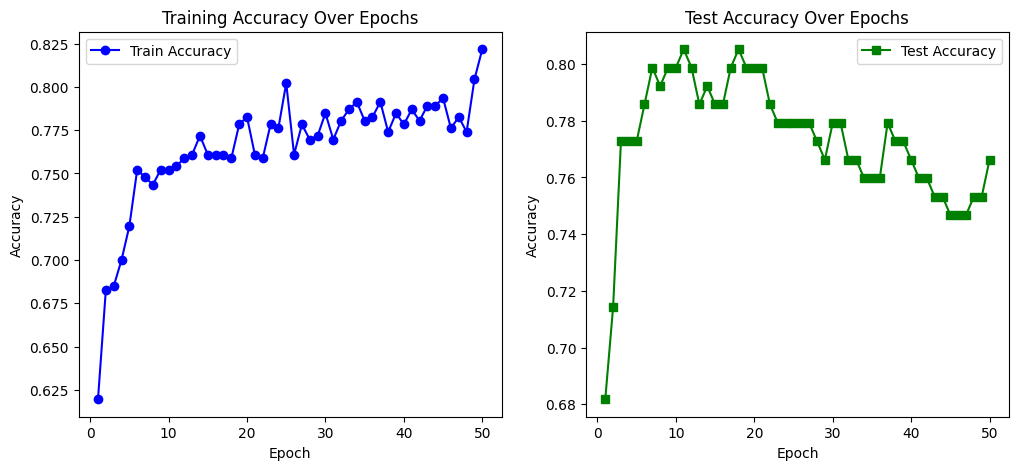

In [264]:
# don't change this cell
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_EPOCHS+1), train_accuracy_list, marker='o', linestyle='-', color='b', label="Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_EPOCHS+1), test_accuracy_list, marker='s', linestyle='-', color='g', label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy Over Epochs")
plt.legend()

plt.show()

In [265]:
print(metrics_df)

   Epoch  Train_Loss  Train_Accuracy  Val_Loss  Val_Accuracy
0      1    0.642477        0.619565  0.663569      0.681818
1      2    0.593916        0.682609  0.628603      0.714286
2      3    0.578848        0.684783  0.587161      0.772727
3      4    0.562737        0.700000  0.558316      0.772727
4      5    0.536642        0.719565  0.530211      0.772727
5      6    0.513989        0.752174  0.514504      0.785714
6      7    0.505466        0.747826  0.507339      0.798701
7      8    0.493736        0.743478  0.495813      0.792208
8      9    0.490700        0.752174  0.484053      0.798701
9     10    0.491757        0.752174  0.477670      0.798701
10    11    0.497852        0.754348  0.472142      0.805195
11    12    0.494818        0.758696  0.465821      0.798701
12    13    0.470701        0.760870  0.453621      0.785714
13    14    0.474837        0.771739  0.445472      0.792208
14    15    0.481189        0.760870  0.439973      0.785714
15    16    0.465399    

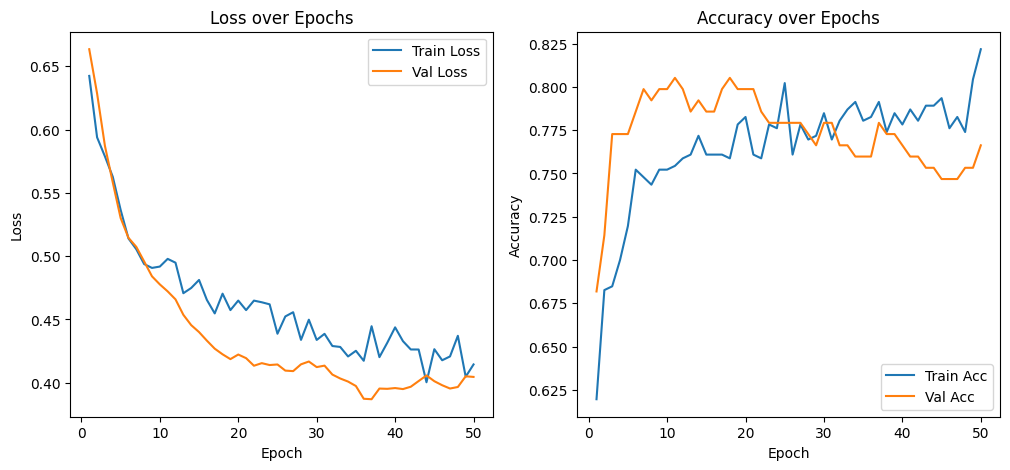

In [266]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(metrics_df['Epoch'], metrics_df['Train_Loss'], label='Train Loss')
plt.plot(metrics_df['Epoch'], metrics_df['Val_Loss'], label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(metrics_df['Epoch'], metrics_df['Train_Accuracy'], label='Train Acc')
plt.plot(metrics_df['Epoch'], metrics_df['Val_Accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()


In [267]:
    kan_model = KAN(
        width=[input_size,32, 16, 1],  # معماری شبکه
        grid=5,  # تعداد نقاط کنترل
        k=3,  # درجه spline
        seed=seed
    )
    

checkpoint directory created: ./model
saving model version 0.0


In [268]:
# import inspect
# print("Available parameters for train method:")
# print(inspect.signature(kan_model.train))

In [269]:
dataset_train = {
    'train_input': X_train.to(device),
    'train_label': y_train.to(device),
    'test_input': X_test_tensor.to(device),
    'test_label': y_test_tensor.to(device)
}
try:
    results = kan_model.fit(dataset_train, opt="Adam", steps=1000, lamb=0.001, lamb_entropy=0.01)


    kan_model.eval()
    with torch.no_grad():
        kan_outputs = kan_model(X_test_tensor.to(device))
        kan_predictions = (kan_outputs > 0.5).float()
        
        y_true = y_test_tensor.cpu().numpy()
        y_pred_kan = kan_predictions.cpu().numpy()
        y_prob_kan = kan_outputs.cpu().numpy()
        
        kan_accuracy = accuracy_score(y_true, y_pred_kan)
        kan_f1 = f1_score(y_true, y_pred_kan)
        kan_roc_auc = roc_auc_score(y_true, y_prob_kan)
        
        print(f"\n{'='*50}")
        print(f"KAN Test Results:")
        print(f"{'='*50}")
        print(f"Accuracy:  {kan_accuracy:.4f}")
        print(f"F1-Score:  {kan_f1:.4f}")
        print(f"ROC-AUC:   {kan_roc_auc:.4f}")
        print(f"{'='*50}\n")
        
        kan_results = {
            'accuracy': kan_accuracy,
            'f1_score': kan_f1,
            'roc_auc': kan_roc_auc,
            'predictions': y_pred_kan,
            'probabilities': y_prob_kan
        }
except Exception as e:
    print("Error:", e)
    kan_results = None


| train_loss: 3.89e-01 | test_loss: 9.62e-01 | reg: 3.81e+03 | : 100%|█| 1000/1000 [01:24<00:00, 11.


saving model version 0.1

KAN Test Results:
Accuracy:  0.6818
F1-Score:  0.4731
ROC-AUC:   0.6675



In [270]:

comparison_data = {
    'Model': ['MLP', 'KAN'],
    'Accuracy': [mlp_accuracy, kan_results['accuracy'] if kan_results else 0],
    'F1-Score': [mlp_f1, kan_results['f1_score'] if kan_results else 0],
    'ROC-AUC': [mlp_roc_auc, kan_results['roc_auc'] if kan_results else 0]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)

  Model  Accuracy  F1-Score   ROC-AUC
0   MLP  0.753247  0.612245  0.832202
1   KAN  0.681818  0.473118  0.667500


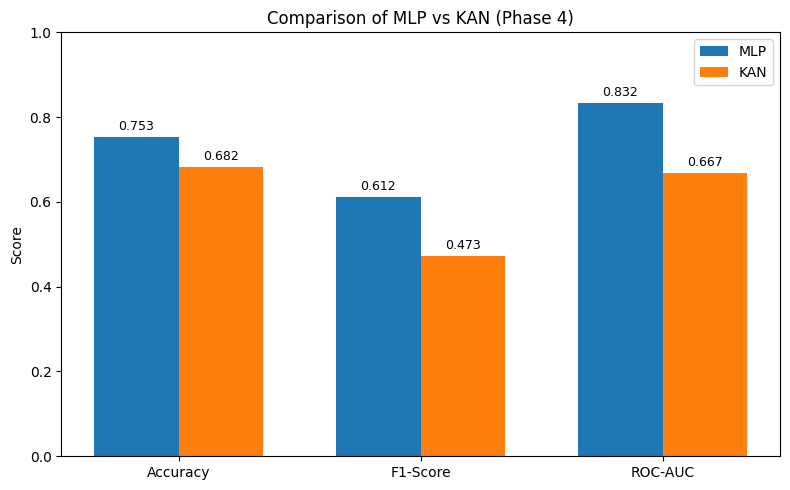

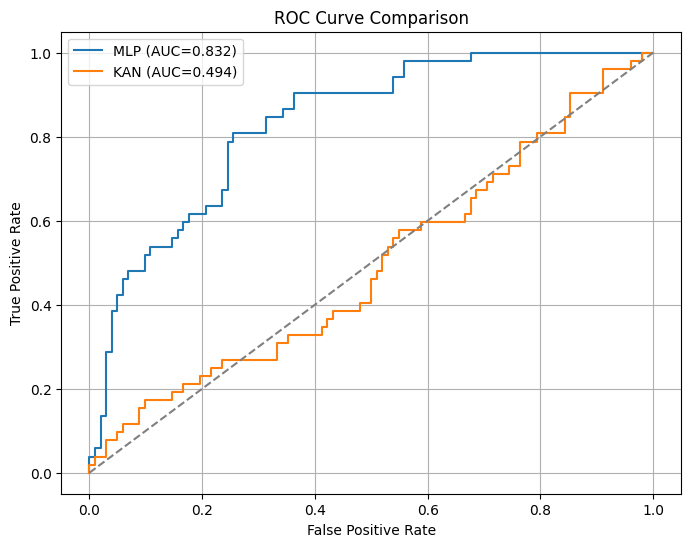

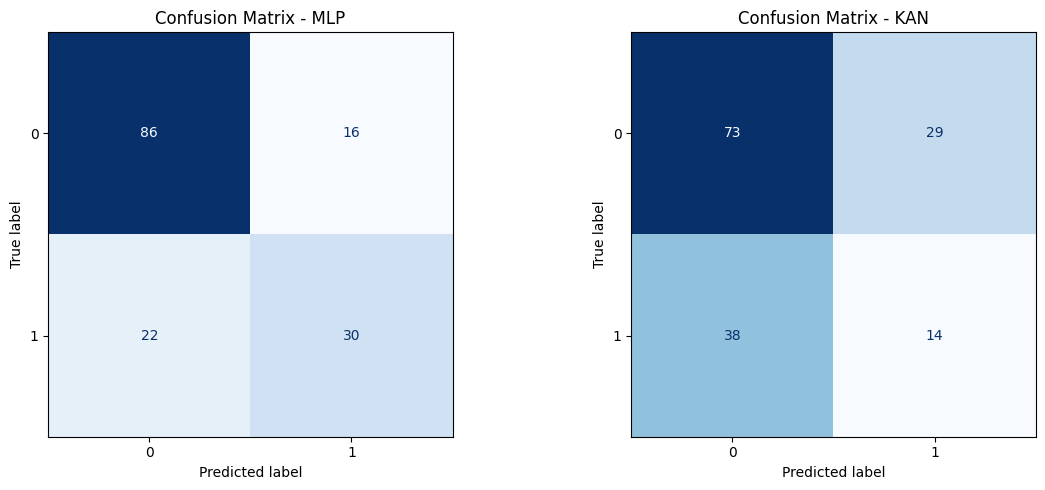

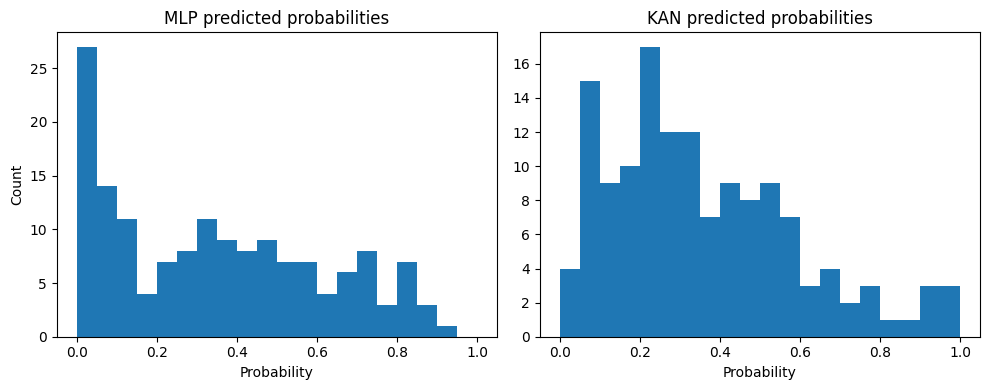

In [271]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay


probs = np.ravel(probs)            
y_true = np.ravel(y_test_org.numpy())
preds = np.ravel(preds)          
y_prob_kan = np.ravel(kan_results['probabilities']) if kan_results else None
y_pred_kan = np.ravel(kan_results['predictions']) if kan_results else None

metrics_names = ['Accuracy','F1-Score','ROC-AUC']
mlp_vals = [mlp_accuracy, mlp_f1, mlp_roc_auc]
kan_vals = [kan_results['accuracy'] if kan_results else 0.0,
            kan_results['f1_score'] if kan_results else 0.0,
            kan_results['roc_auc'] if kan_results else 0.0]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width/2, mlp_vals, width, label='MLP')
rects2 = ax.bar(x + width/2, kan_vals, width, label='KAN')
ax.set_ylabel('Score')
ax.set_title('Comparison of MLP vs KAN (Phase 4)')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0,1.0)
ax.legend()
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}', xy=(rect.get_x()+rect.get_width()/2, height),
                xytext=(0,3), textcoords='offset points', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
if probs is not None:
    fpr_m, tpr_m, _ = roc_curve(y_true, probs)
    auc_m = auc(fpr_m, tpr_m)
    plt.plot(fpr_m, tpr_m, label=f'MLP (AUC={auc_m:.3f})')
if y_prob_kan is not None:
    fpr_k, tpr_k, _ = roc_curve(y_true, y_prob_kan)
    auc_k = auc(fpr_k, tpr_k)
    plt.plot(fpr_k, tpr_k, label=f'KAN (AUC={auc_k:.3f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12,5))
cm_mlp = confusion_matrix(y_true, preds)
disp = ConfusionMatrixDisplay(cm_mlp)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix - MLP')

if y_pred_kan is not None:
    cm_kan = confusion_matrix(y_true, y_pred_kan)
    disp2 = ConfusionMatrixDisplay(cm_kan)
    disp2.plot(ax=axes[1], cmap='Blues', colorbar=False)
    axes[1].set_title('Confusion Matrix - KAN')
else:
    axes[1].text(0.5,0.5,'KAN predictions not available', ha='center')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(probs, bins=20, range=(0,1))
plt.title('MLP predicted probabilities')
plt.xlabel('Probability')
plt.ylabel('Count')

plt.subplot(1,2,2)
if y_prob_kan is not None:
    plt.hist(y_prob_kan, bins=20, range=(0,1))
    plt.title('KAN predicted probabilities')
    plt.xlabel('Probability')
else:
    plt.text(0.5,0.5,'KAN probabilities not available',ha='center')
plt.tight_layout()
plt.show()


